## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

- **Percepción (S):** ingreso mensual del solicitante, monto solicitado e información sobre si tiene historial moroso.
- **Acciones (A):** aprobar la solicitud, aprobar con condiciones o rechazarla.
- **Entorno (E):** banco, solicitantes de crédito, registros financieros y políticas crediticias.
- **Objetivo:** tomar una decisión adecuada sobre la solicitud, reduciendo el riesgo de incumplimiento para el banco.
- **Medida de desempeño (P):** porcentaje de decisiones correctas, reducción de préstamos incumplidos, rapidez de evaluación y bajo número de rechazos injustificados.

### Justificación de las reglas

Las reglas consideran que una relación baja entre el monto solicitado y el ingreso representa un menor riesgo para el banco. Si la relación aumenta, se requieren condiciones adicionales para reducir la posibilidad de incumplimiento. El historial moroso también incrementa el riesgo, por lo que limita la aprobación directa o provoca el rechazo de la solicitud.

### Código

In [3]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    if ingreso_mensual <= 0:
        return "rechazar", "el ingreso mensual debe ser mayor que cero"

    if monto_solicitado <= 0:
        return "rechazar", "el monto solicitado debe ser mayor que cero"

    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        if relacion > 0.5:
            return "rechazar", f"relación monto/ingreso de {relacion:.2f} con historial moroso"
        else:
            return "aprobar con condiciones", f"relación de {relacion:.2f}, pero presenta historial moroso"

    if relacion <= 0.5:
        return "aprobar", f"relación monto/ingreso baja de {relacion:.2f} y sin historial moroso"
    elif relacion <= 1.0:
        return "aprobar con condiciones", f"relación monto/ingreso moderada de {relacion:.2f}"
    else:
        return "rechazar", f"relación monto/ingreso alta de {relacion:.2f}"
        

### Simulación y pruebas

Se evalúan seis solicitudes con diferentes ingresos, montos e historiales. La segunda prueba representa un caso límite, porque la relación entre el monto solicitado y el ingreso mensual es exactamente 0.50.

In [4]:
casos_prueba = [
    (4000, 1000, False),
    (4000, 2000, False),  # Caso límite: relación = 0.50
    (4000, 3000, False),
    (4000, 5000, False),
    (4000, 1000, True),
    (4000, 3000, True)
]

for numero, (ingreso, monto, moroso) in enumerate(casos_prueba, start=1):
    accion, motivo = agente_credito(ingreso, monto, moroso)
    relacion = monto / ingreso

    print(f"Prueba {numero}")
    print(f"Ingreso: S/ {ingreso}")
    print(f"Monto solicitado: S/ {monto}")
    print(f"Historial moroso: {moroso}")
    print(f"Relación monto/ingreso: {relacion:.2f}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 50)

Prueba 1
Ingreso: S/ 4000
Monto solicitado: S/ 1000
Historial moroso: False
Relación monto/ingreso: 0.25
Decisión: aprobar
Motivo: relación monto/ingreso baja de 0.25 y sin historial moroso
--------------------------------------------------
Prueba 2
Ingreso: S/ 4000
Monto solicitado: S/ 2000
Historial moroso: False
Relación monto/ingreso: 0.50
Decisión: aprobar
Motivo: relación monto/ingreso baja de 0.50 y sin historial moroso
--------------------------------------------------
Prueba 3
Ingreso: S/ 4000
Monto solicitado: S/ 3000
Historial moroso: False
Relación monto/ingreso: 0.75
Decisión: aprobar con condiciones
Motivo: relación monto/ingreso moderada de 0.75
--------------------------------------------------
Prueba 4
Ingreso: S/ 4000
Monto solicitado: S/ 5000
Historial moroso: False
Relación monto/ingreso: 1.25
Decisión: rechazar
Motivo: relación monto/ingreso alta de 1.25
--------------------------------------------------
Prueba 5
Ingreso: S/ 4000
Monto solicitado: S/ 1000
Historial

### Visualización

Se generan 200 solicitudes aleatorias y se representa la relación entre el monto solicitado y el ingreso mensual. Cada punto se colorea según la decisión tomada por el agente.

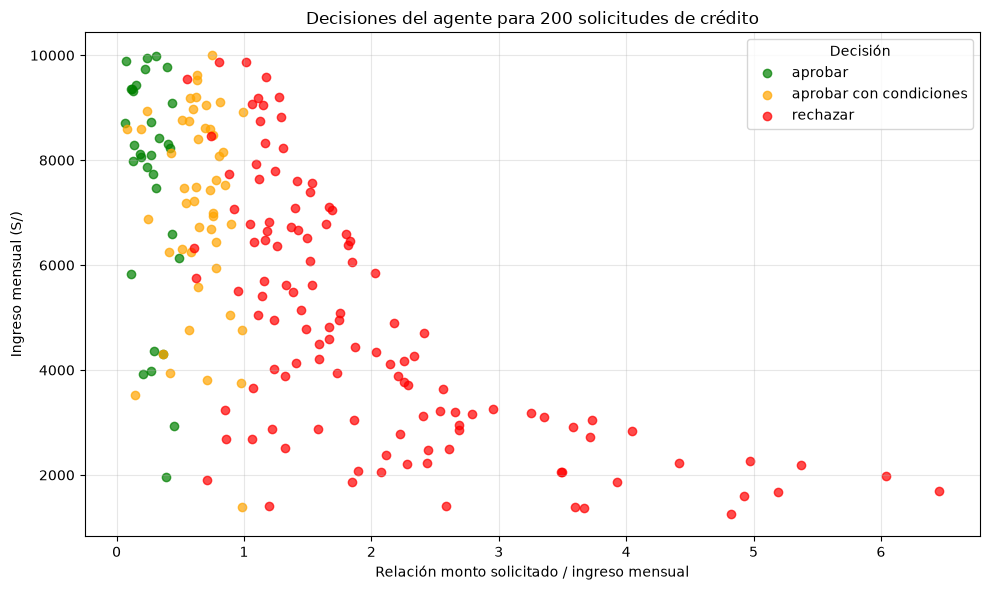

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generación de 200 solicitudes aleatorias
ingresos = np.random.randint(1200, 10001, 200)
montos = np.random.randint(500, 12001, 200)
historiales = np.random.choice(
    [True, False],
    size=200,
    p=[0.25, 0.75]
)

relaciones = montos / ingresos

decisiones = np.array([
    agente_credito(ingreso, monto, historial)[0]
    for ingreso, monto, historial in zip(ingresos, montos, historiales)
])

colores = {
    "aprobar": "green",
    "aprobar con condiciones": "orange",
    "rechazar": "red"
}

plt.figure(figsize=(10, 6))

for accion, color in colores.items():
    seleccion = decisiones == accion
    plt.scatter(
        relaciones[seleccion],
        ingresos[seleccion],
        color=color,
        label=accion,
        alpha=0.7
    )

plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Decisiones del agente para 200 solicitudes de crédito")
plt.legend(title="Decisión")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()